# 02 — Exploratory Data Analysis
**London Crime Analysis (2020–2024)**

We explore crime trends over time, by borough, by crime type, and seasonal patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
BLUE = '#1A3A5C'
RED  = '#C0392B'

df = pd.read_csv('../data/processed/london_crime_clean.csv', parse_dates=['month'])
print(f'Loaded {len(df):,} rows | {df["year"].min()}–{df["year"].max()}')
df.head(3)

Loaded 3,399,506 rows | 2023–2026


,month,year,month_num,month_name,year_month,crime_type,borough,lsoa_code,lsoa_name,latitude,longitude,last_outcome_category
0,2023-04-01,2023,4,April,2023-04,Vehicle Crime,Adur,E01031372,Adur 004E,50.834677,-0.254186,Investigation complete; no suspect identified
1,2023-04-01,2023,4,April,2023-04,Violence And Sexual Offences,Arun,E01031392,Arun 001C,50.852819,-0.559343,Investigation complete; no suspect identified
2,2023-04-01,2023,4,April,2023-04,Violence And Sexual Offences,Arun,E01031425,Arun 002C,50.865992,-0.405658,Investigation complete; no suspect identified


## 1. Total Crime Volume Over Time (Monthly)

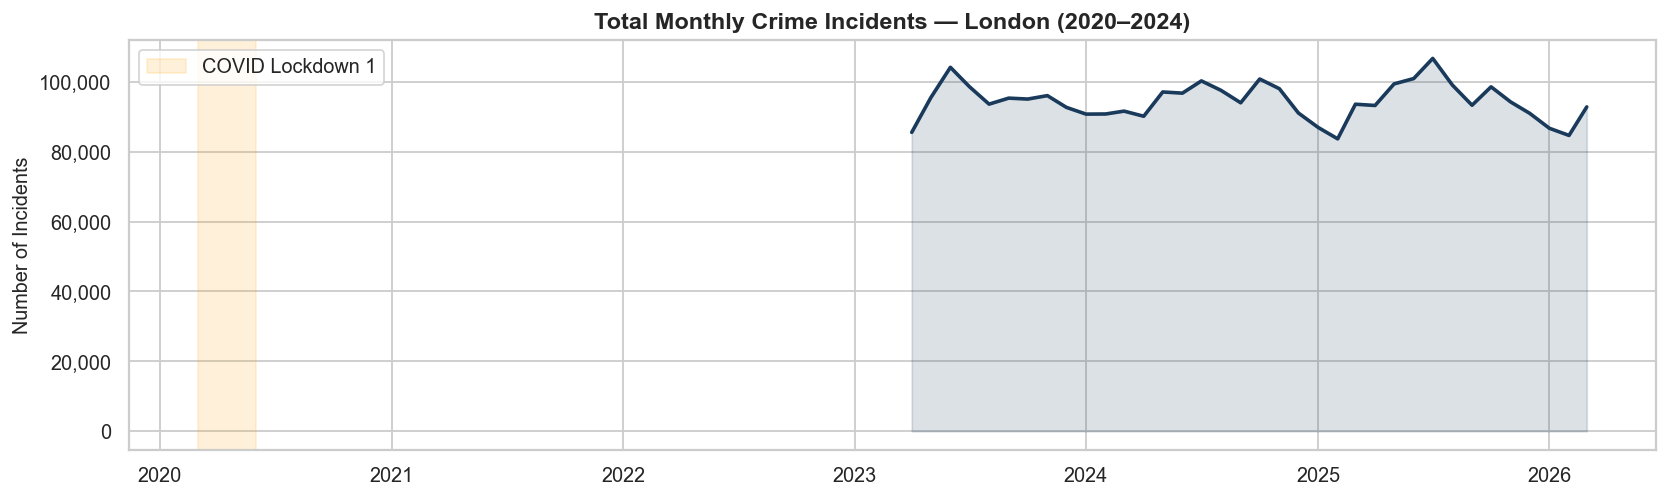

Saved chart_01


In [2]:
monthly = df.groupby('year_month').size().reset_index(name='crimes')
monthly['date'] = pd.to_datetime(monthly['year_month'])
monthly = monthly.sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['date'], monthly['crimes'], color=BLUE, linewidth=2)
ax.fill_between(monthly['date'], monthly['crimes'], alpha=0.15, color=BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Total Monthly Crime Incidents — London (2020–2024)')
ax.set_xlabel('')
ax.set_ylabel('Number of Incidents')

# Annotate COVID lockdown
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
           alpha=0.15, color='orange', label='COVID Lockdown 1')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/chart_01_monthly_trend.png', bbox_inches='tight')
plt.show()
print('Saved chart_01')

## 2. Top 10 Crime Types

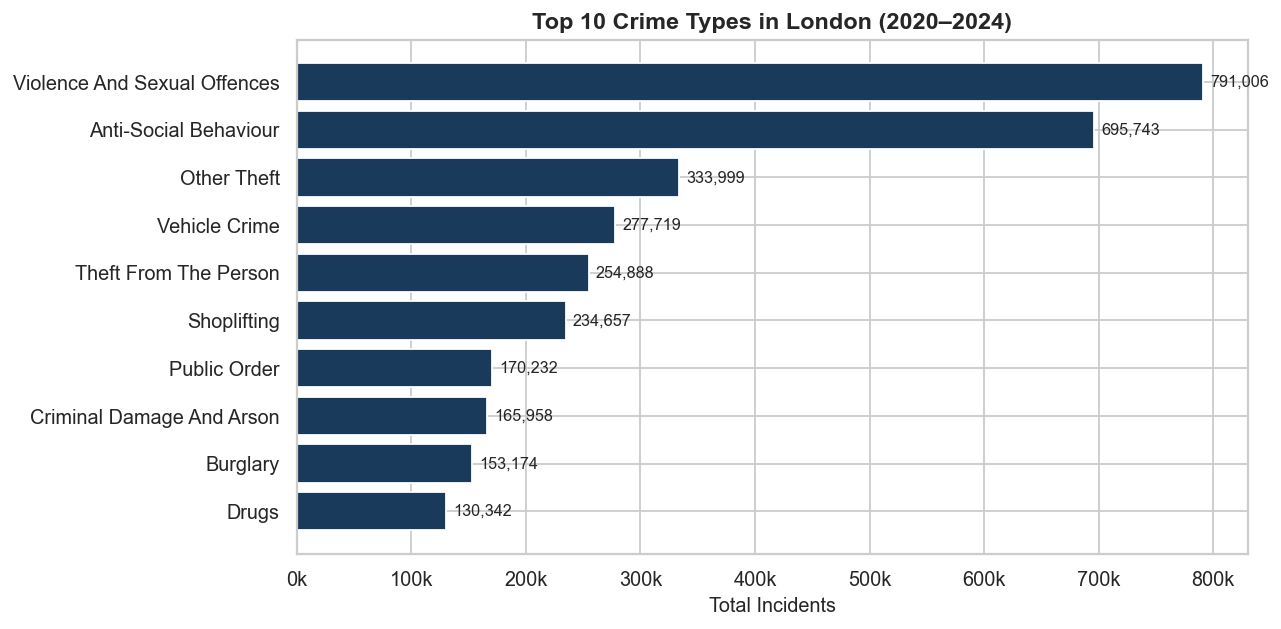

In [3]:
top_crimes = df['crime_type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_crimes.index[::-1], top_crimes.values[::-1], color=BLUE)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title('Top 10 Crime Types in London (2020–2024)')
ax.set_xlabel('Total Incidents')
plt.tight_layout()
plt.savefig('../data/processed/chart_02_crime_types.png', bbox_inches='tight')
plt.show()

## 3. Top 10 Boroughs by Total Crime

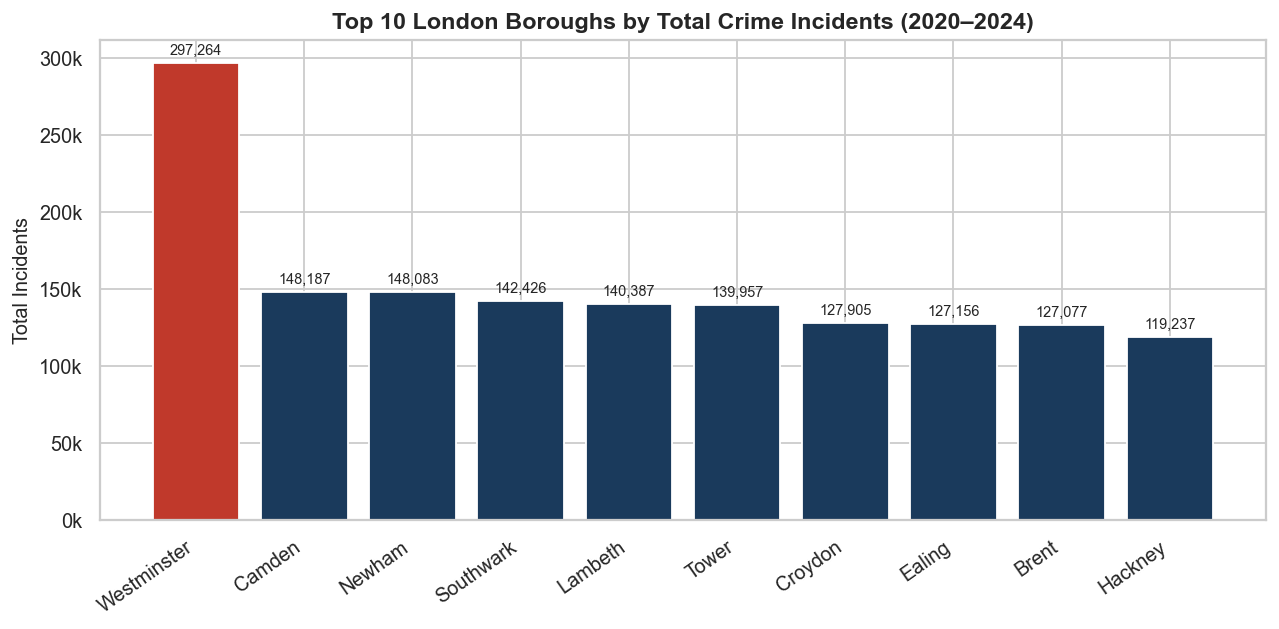

In [4]:
borough_counts = df.groupby('borough').size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [RED if i == 0 else BLUE for i in range(len(borough_counts))]
bars = ax.bar(borough_counts.index, borough_counts.values, color=colors)
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8, rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title('Top 10 London Boroughs by Total Crime Incidents (2020–2024)')
ax.set_ylabel('Total Incidents')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/chart_03_boroughs.png', bbox_inches='tight')
plt.show()

## 4. Crime Trend by Year — Has London Got Safer?

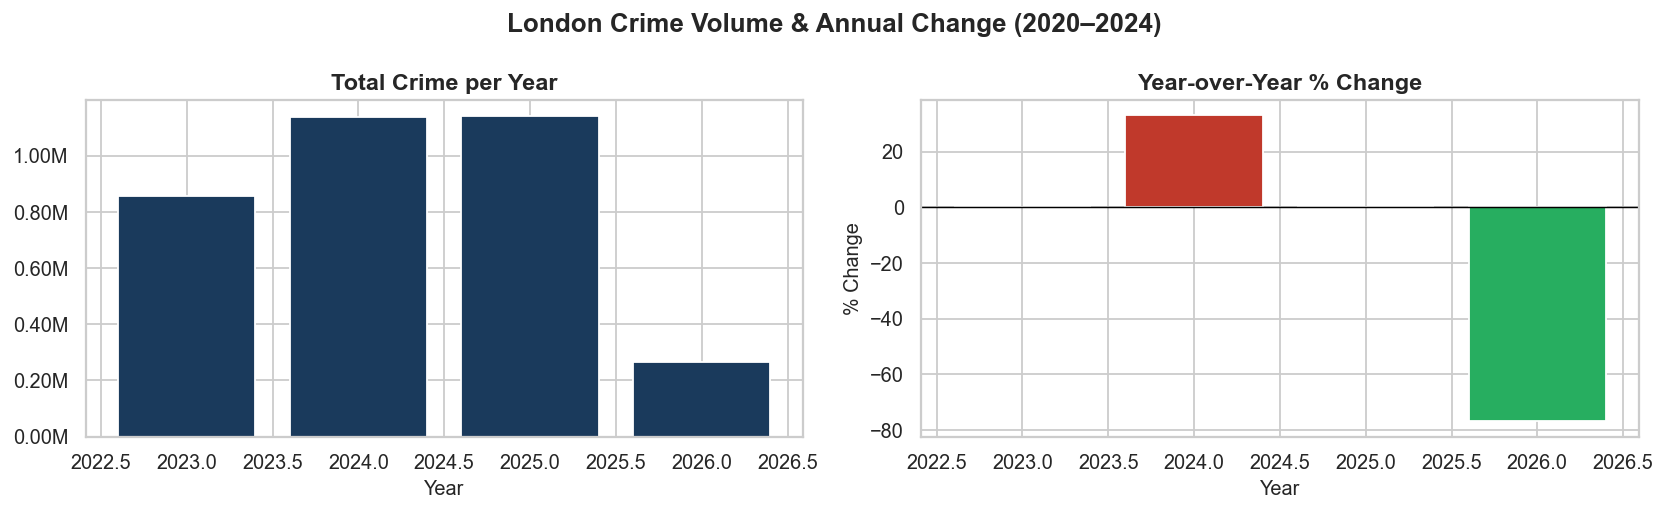

   year   crimes
0  2023   856305
1  2024  1138656
2  2025  1140416
3  2026   264129


In [5]:
yearly = df.groupby('year').size().reset_index(name='crimes')
pct_change = yearly['crimes'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Total per year
axes[0].bar(yearly['year'], yearly['crimes'], color=BLUE)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
axes[0].set_title('Total Crime per Year')
axes[0].set_xlabel('Year')

# YoY % change
colors_pct = [RED if v > 0 else '#27AE60' for v in pct_change.fillna(0)]
axes[1].bar(yearly['year'], pct_change.fillna(0), color=colors_pct)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year % Change')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Change')

plt.suptitle('London Crime Volume & Annual Change (2020–2024)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/chart_04_yearly.png', bbox_inches='tight')
plt.show()

print(yearly)

## 5. Seasonal Patterns — Which Month Has Most Crime?

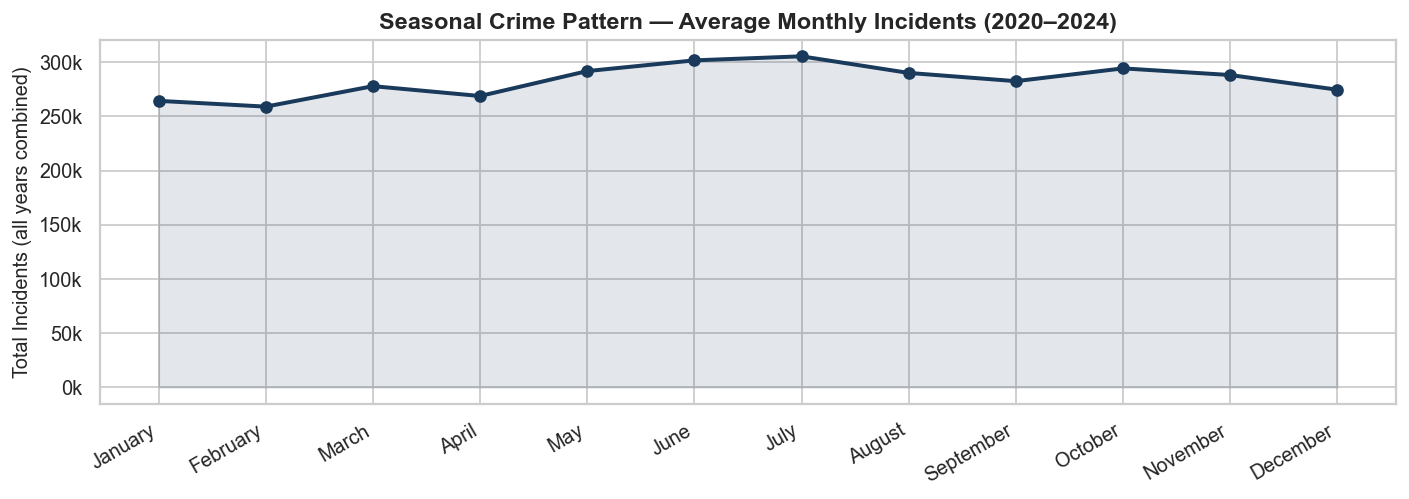

Highest crime month: July (305,505 incidents)
Lowest crime month:  February (259,071 incidents)


In [6]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
seasonal = df.groupby('month_name').size().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(seasonal.index, seasonal.values, marker='o', color=BLUE, linewidth=2.2)
ax.fill_between(range(len(seasonal)), seasonal.values, alpha=0.12, color=BLUE)
ax.set_xticks(range(len(seasonal)))
ax.set_xticklabels(seasonal.index, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title('Seasonal Crime Pattern — Average Monthly Incidents (2020–2024)')
ax.set_ylabel('Total Incidents (all years combined)')
plt.tight_layout()
plt.savefig('../data/processed/chart_05_seasonal.png', bbox_inches='tight')
plt.show()

print('Highest crime month:', seasonal.idxmax(), f'({seasonal.max():,.0f} incidents)')
print('Lowest crime month: ', seasonal.idxmin(), f'({seasonal.min():,.0f} incidents)')

## 6. Heatmap — Crime Type by Borough (Top 8 each)

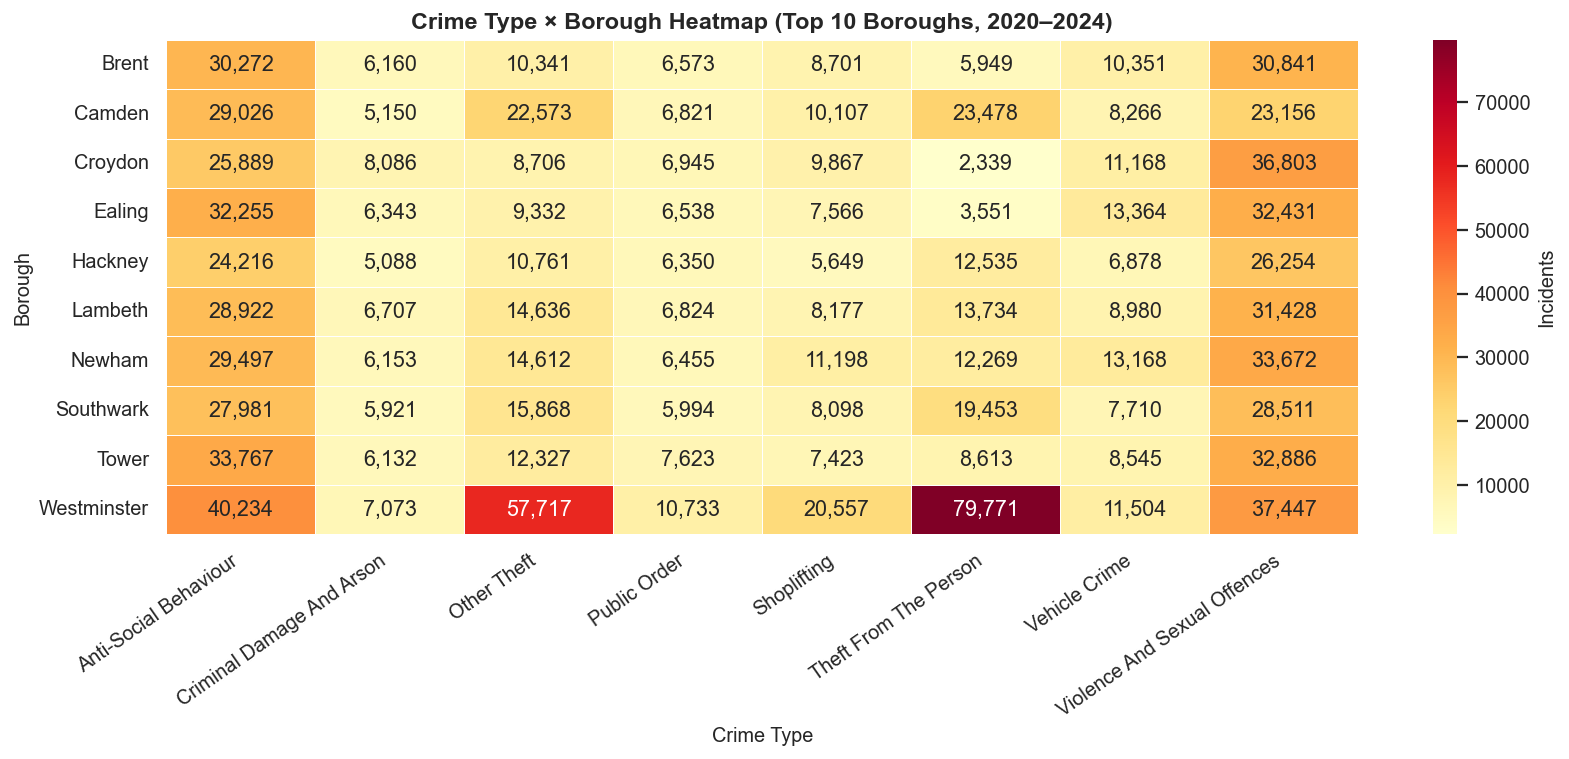

In [7]:
top_boroughs = df['borough'].value_counts().head(10).index
top_types    = df['crime_type'].value_counts().head(8).index

heat_data = (
    df[df['borough'].isin(top_boroughs) & df['crime_type'].isin(top_types)]
    .groupby(['borough', 'crime_type'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heat_data, cmap='YlOrRd', fmt=',d', annot=True,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Incidents'})
ax.set_title('Crime Type × Borough Heatmap (Top 10 Boroughs, 2020–2024)')
ax.set_xlabel('Crime Type')
ax.set_ylabel('Borough')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/chart_06_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Key Numbers — Copy These Into Your README

In [8]:
print('=== KEY FINDINGS FOR README ===')
print(f"Total incidents analysed: {len(df):,}")
print(f"Most common crime:        {df['crime_type'].value_counts().idxmax()}")
print(f"Highest crime borough:    {df['borough'].value_counts().idxmax()}")
print(f"Highest crime month:      {df['month_name'].value_counts().idxmax()}")
print()

yr_23 = df[df['year']==2023].shape[0]
yr_25 = df[df['year']==2025].shape[0]
change = (yr_25 - yr_23) / yr_23 * 100
print(f"Crime in 2023: {yr_23:,}")
print(f"Crime in 2025: {yr_25:,}")
print(f"Overall change 2023→2025: {change:+.1f}%")

=== KEY FINDINGS FOR README ===
Total incidents analysed: 3,399,506
Most common crime:        Violence And Sexual Offences
Highest crime borough:    Westminster
Highest crime month:      July

Crime in 2023: 856,305
Crime in 2025: 1,140,416
Overall change 2023→2025: +33.2%
